In [2]:
# ====================================
# 1. Imports
# ====================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

In [3]:
# ====================================
# 2. Load Data
# ====================================

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_excel(file_name)

df.head()

Saving claims_dataset_v1.xlsx to claims_dataset_v1.xlsx


,Claim_ID,Policy_ID,Customer_ID,Branch,Coverage,Claim_Type,Province,Policy_Start,Policy_End,Accident_Date,Report_Date,Payment_Date,Accident_Year,Accident_Month,Report_Delay_Days,Development_Month,Premium,Sum_Insured,Paid_Amount,Outstanding_Reserve,Incurred,Claim_Count,Status,Customer_Age,Customer_Gender,Vehicle_Age,Fraud_Flag
0,CLM0000001,POL001143,CUS000794,Comercio,Integral,Theft,Córdoba,2023-02-13,2024-09-09,2023-09-10,2023-09-15,2024-02-29,2023,9,5,6,195536,34833375,4614697,1288424,5903121,1,Open,81,Female,NaN,0
1,CLM0000002,POL005361,CUS000703,Comercio,Integral,Fire,Neuquén,2023-11-06,2025-08-08,2024-08-08,2024-08-18,2025-02-12,2024,8,10,7,151730,11646516,295524,32751,328275,1,Open,27,Male,NaN,0
2,CLM0000003,POL003207,CUS002613,Vida,Individual,Death,Buenos Aires,2016-07-22,2018-05-10,2017-05-10,2017-05-12,2017-09-01,2017,5,2,4,400554,14690589,36224539,0,36224539,1,Closed,62,Male,NaN,1
3,CLM0000004,POL001826,CUS010240,Hogar,Premium,Water Damage,Buenos Aires,2016-03-12,2019-07-18,2018-07-18,2018-08-17,2019-06-18,2018,7,30,12,174835,15466625,1241065,0,1241065,1,Closed,48,Male,NaN,0
4,CLM0000005,POL003772,CUS010277,Auto,Third Party,Theft,Neuquén,2015-05-11,2019-02-04,2018-02-04,2018-03-03,2019-02-01,2018,2,27,13,229881,15008264,452276,0,452276,1,Closed,50,Female,23.00,0


In [4]:
# ====================================
# 3. Basic Data Review
# ====================================

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 35000
Columns: 27
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Claim_ID             35000 non-null  object        
 1   Policy_ID            35000 non-null  object        
 2   Customer_ID          35000 non-null  object        
 3   Branch               35000 non-null  object        
 4   Coverage             35000 non-null  object        
 5   Claim_Type           35000 non-null  object        
 6   Province             35000 non-null  object        
 7   Policy_Start         35000 non-null  datetime64[ns]
 8   Policy_End           35000 non-null  datetime64[ns]
 9   Accident_Date        35000 non-null  datetime64[ns]
 10  Report_Date          35000 non-null  datetime64[ns]
 11  Payment_Date         35000 non-null  datetime64[ns]
 12  Accident_Year        35000 non-null  int64         
 13  Acciden

In [5]:
df.describe(include="all")

,Claim_ID,Policy_ID,Customer_ID,Branch,Coverage,Claim_Type,Province,Policy_Start,Policy_End,Accident_Date,Report_Date,Payment_Date,Accident_Year,Accident_Month,Report_Delay_Days,Development_Month,Premium,Sum_Insured,Paid_Amount,Outstanding_Reserve,Incurred,Claim_Count,Status,Customer_Age,Customer_Gender,Vehicle_Age,Fraud_Flag
count,35000,35000,35000,35000,35000,35000,35000,35000,35000,35000,35000,35000,"35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00",35000,"35,000.00",35000,"15,671.00","35,000.00"
unique,35000,8834,13516,5,8,10,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,2,NaN,NaN
top,CLM0035000,POL000579,CUS014039,Auto,Third Party,Fire,Córdoba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Closed,NaN,Female,NaN,NaN
freq,1,14,10,15671,7841,6909,4504,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26217,NaN,17565,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-30 02:33:52.457142784,2021-01-04 19:52:43.885714176,2020-01-05 19:52:43.885714432,2020-01-27 20:27:24.891428608,2020-10-25 19:44:20.297142784,"2,019.52",6.51,22.02,10.32,"504,784.77","27,867,624.77","4,680,963.45","494,401.01","5,175,364.46",1.00,NaN,50.83,NaN,12.01,0.02
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2011-10-06 00:00:00,2016-01-01 00:00:00,2015-01-01 00:00:00,2015-01-03 00:00:00,2015-02-11 00:00:00,"2,015.00",1.00,0.00,1.00,"40,011.00","3,000,119.00","30,084.00",0.00,"30,084.00",1.00,NaN,18.00,NaN,0.00,0.00
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2015-11-06 18:00:00,2018-07-14 00:00:00,2017-07-14 00:00:00,2017-08-07 00:00:00,2018-05-04 00:00:00,"2,017.00",4.00,11.00,6.00,"127,928.00","10,717,548.50","1,005,576.75",0.00,"1,077,575.25",1.00,NaN,34.00,NaN,6.00,0.00
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018-04-20 00:00:00,2020-12-28 00:00:00,2019-12-29 00:00:00,2020-01-20 00:00:00,2020-10-15 00:00:00,"2,019.00",7.00,22.00,10.00,"191,026.00","17,514,225.00","1,929,914.00",0.00,"2,092,660.00",1.00,NaN,51.00,NaN,12.00,0.00
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020-11-03 00:00:00,2023-07-12 00:00:00,2022-07-12 00:00:00,2022-08-04 00:00:00,2023-05-03 00:00:00,"2,022.00",9.00,33.00,15.00,"423,541.00","37,391,877.50","3,793,202.00","11,451.00","4,232,681.25",1.00,NaN,68.00,NaN,18.00,0.00
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-11-05 00:00:00,2025-12-31 00:00:00,2024-12-31 00:00:00,2025-02-12 00:00:00,2026-07-23 00:00:00,"2,024.00",12.00,44.00,20.00,"2,999,722.00","99,994,592.00","49,991,061.00","38,389,212.00","87,805,668.00",1.00,NaN,84.00,NaN,24.00,1.00


In [6]:
# ====================================
# 4. Data Quality Checks
# ====================================

missing_values = df.isna().sum().sort_values(ascending=False)
missing_values

,0
Vehicle_Age,19329
Policy_ID,0
Claim_ID,0
Branch,0
Coverage,0
Claim_Type,0
Province,0
Policy_Start,0
Policy_End,0
Accident_Date,0


In [7]:
duplicated_rows = df.duplicated().sum()
duplicated_claim_ids = df["Claim_ID"].duplicated().sum()

print("Duplicated rows:", duplicated_rows)
print("Duplicated Claim_ID:", duplicated_claim_ids)

Duplicated rows: 0
Duplicated Claim_ID: 0


In [8]:
# Validaciones básicas

checks = {
    "Unique Claim_ID": df["Claim_ID"].is_unique,
    "Paid Amount >= 0": (df["Paid_Amount"] >= 0).all(),
    "Premium >= 0": (df["Premium"] >= 0).all(),
    "Sum Insured >= 0": (df["Sum_Insured"] >= 0).all(),
    "Report Date >= Accident Date": (df["Report_Date"] >= df["Accident_Date"]).all(),
    "Payment Date >= Report Date": (df["Payment_Date"] >= df["Report_Date"]).all(),
    "Incurred = Paid + Outstanding": np.allclose(
        df["Incurred"],
        df["Paid_Amount"] + df["Outstanding_Reserve"]
    )
}

checks

{'Unique Claim_ID': True,
 'Paid Amount >= 0': np.True_,
 'Premium >= 0': np.True_,
 'Sum Insured >= 0': np.True_,
 'Report Date >= Accident Date': np.True_,
 'Payment Date >= Report Date': np.True_,
 'Incurred = Paid + Outstanding': True}

In [9]:
# ====================================
# 5. Feature Engineering
# ====================================

df["Loss_Ratio"] = df["Incurred"] / df["Premium"]
df["Reserve_Ratio"] = df["Outstanding_Reserve"] / df["Incurred"]
df["Paid_to_Sum_Insured"] = df["Paid_Amount"] / df["Sum_Insured"]

df.replace([np.inf, -np.inf], np.nan, inplace=True)

df.head()

,Claim_ID,Policy_ID,Customer_ID,Branch,Coverage,Claim_Type,Province,Policy_Start,Policy_End,Accident_Date,Report_Date,Payment_Date,Accident_Year,Accident_Month,Report_Delay_Days,Development_Month,Premium,Sum_Insured,Paid_Amount,Outstanding_Reserve,Incurred,Claim_Count,Status,Customer_Age,Customer_Gender,Vehicle_Age,Fraud_Flag,Loss_Ratio,Reserve_Ratio,Paid_to_Sum_Insured
0,CLM0000001,POL001143,CUS000794,Comercio,Integral,Theft,Córdoba,2023-02-13,2024-09-09,2023-09-10,2023-09-15,2024-02-29,2023,9,5,6,195536,34833375,4614697,1288424,5903121,1,Open,81,Female,NaN,0,30.19,0.22,0.13
1,CLM0000002,POL005361,CUS000703,Comercio,Integral,Fire,Neuquén,2023-11-06,2025-08-08,2024-08-08,2024-08-18,2025-02-12,2024,8,10,7,151730,11646516,295524,32751,328275,1,Open,27,Male,NaN,0,2.16,0.10,0.03
2,CLM0000003,POL003207,CUS002613,Vida,Individual,Death,Buenos Aires,2016-07-22,2018-05-10,2017-05-10,2017-05-12,2017-09-01,2017,5,2,4,400554,14690589,36224539,0,36224539,1,Closed,62,Male,NaN,1,90.44,0.00,2.47
3,CLM0000004,POL001826,CUS010240,Hogar,Premium,Water Damage,Buenos Aires,2016-03-12,2019-07-18,2018-07-18,2018-08-17,2019-06-18,2018,7,30,12,174835,15466625,1241065,0,1241065,1,Closed,48,Male,NaN,0,7.10,0.00,0.08
4,CLM0000005,POL003772,CUS010277,Auto,Third Party,Theft,Neuquén,2015-05-11,2019-02-04,2018-02-04,2018-03-03,2019-02-01,2018,2,27,13,229881,15008264,452276,0,452276,1,Closed,50,Female,23.00,0,1.97,0.00,0.03


# **EDA UNIVARIADO**

In [10]:
# ====================================
# 6. Univariate Analysis - Categorical
# ====================================

categorical_cols = [
    "Branch",
    "Coverage",
    "Claim_Type",
    "Province",
    "Status",
    "Customer_Gender",
    "Fraud_Flag"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    display(df[col].value_counts(dropna=False))


--- Branch ---


,count
Branch,
Auto,15671
ART,7083
Hogar,5346
Vida,3479
Comercio,3421



--- Coverage ---


,count
Coverage,
Third Party,7841
Full Coverage,7830
Workers Compensation,7083
Integral,3421
Basic,2685
Premium,2661
Collective,1780
Individual,1699



--- Claim_Type ---


...

,count
Status,
Closed,26217
Open,8783



--- Customer_Gender ---


,count
Customer_Gender,
Female,17565
Male,17435



--- Fraud_Flag ---


,count
Fraud_Flag,
0,34285
1,715


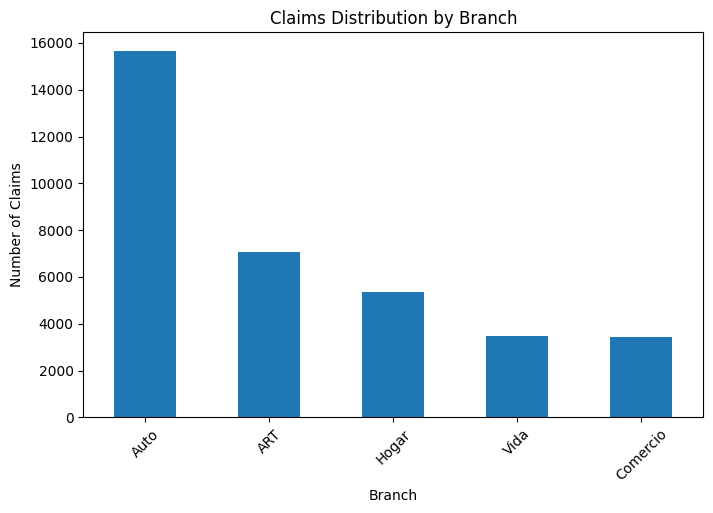

In [11]:
# Branch distribution

branch_counts = df["Branch"].value_counts()

plt.figure(figsize=(8,5))
branch_counts.plot(kind="bar")
plt.title("Claims Distribution by Branch")
plt.xlabel("Branch")
plt.ylabel("Number of Claims")
plt.xticks(rotation=45)
plt.show()

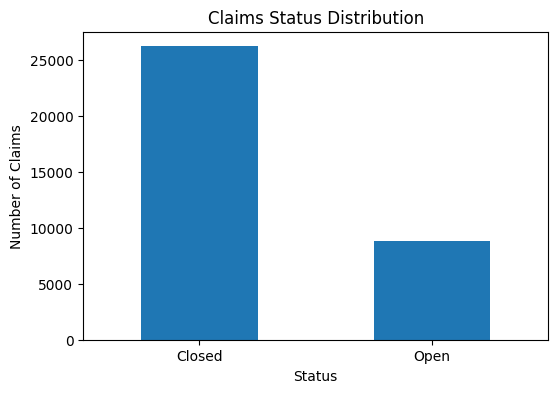

In [12]:
# Status distribution

status_counts = df["Status"].value_counts()

plt.figure(figsize=(6,4))
status_counts.plot(kind="bar")
plt.title("Claims Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Claims")
plt.xticks(rotation=0)
plt.show()

In [13]:
# ====================================
# 7. Univariate Analysis - Numerical
# ====================================

numeric_cols = [
    "Premium",
    "Sum_Insured",
    "Paid_Amount",
    "Outstanding_Reserve",
    "Incurred",
    "Report_Delay_Days",
    "Development_Month",
    "Customer_Age",
    "Vehicle_Age",
    "Loss_Ratio",
    "Reserve_Ratio",
    "Paid_to_Sum_Insured"
]

df[numeric_cols].describe()

,Premium,Sum_Insured,Paid_Amount,Outstanding_Reserve,Incurred,Report_Delay_Days,Development_Month,Customer_Age,Vehicle_Age,Loss_Ratio,Reserve_Ratio,Paid_to_Sum_Insured
count,"35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","35,000.00","15,671.00","35,000.00","35,000.00","35,000.00"
mean,"504,784.77","27,867,624.77","4,680,963.45","494,401.01","5,175,364.46",22.02,10.32,50.83,12.01,23.42,0.07,0.20
std,"714,184.04","24,776,576.74","8,539,016.16","2,279,923.30","9,669,797.57",12.99,5.16,19.38,7.20,62.77,0.13,0.41
min,"40,011.00","3,000,119.00","30,084.00",0.00,"30,084.00",0.00,1.00,18.00,0.00,0.10,0.00,0.00
25%,"127,928.00","10,717,548.50","1,005,576.75",0.00,"1,077,575.25",11.00,6.00,34.00,6.00,3.75,0.00,0.05
50%,"191,026.00","17,514,225.00","1,929,914.00",0.00,"2,092,660.00",22.00,10.00,51.00,12.00,8.77,0.00,0.11
75%,"423,541.00","37,391,877.50","3,793,202.00","11,451.00","4,232,681.25",33.00,15.00,68.00,18.00,16.46,0.05,0.20
max,"2,999,722.00","99,994,592.00","49,991,061.00","38,389,212.00","87,805,668.00",44.00,20.00,84.00,24.00,"1,378.63",0.44,8.59


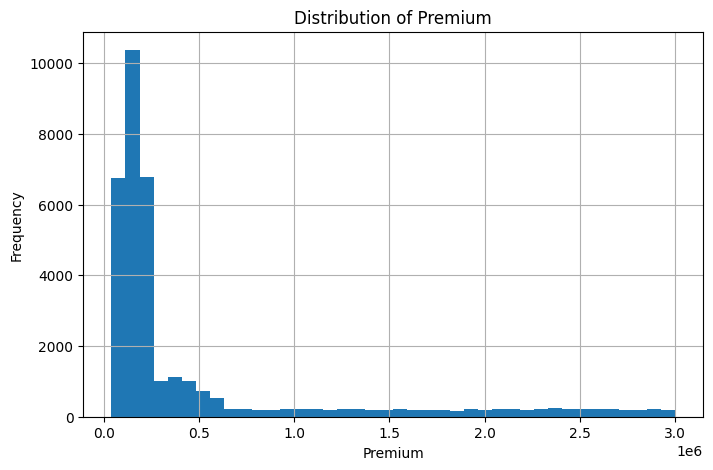

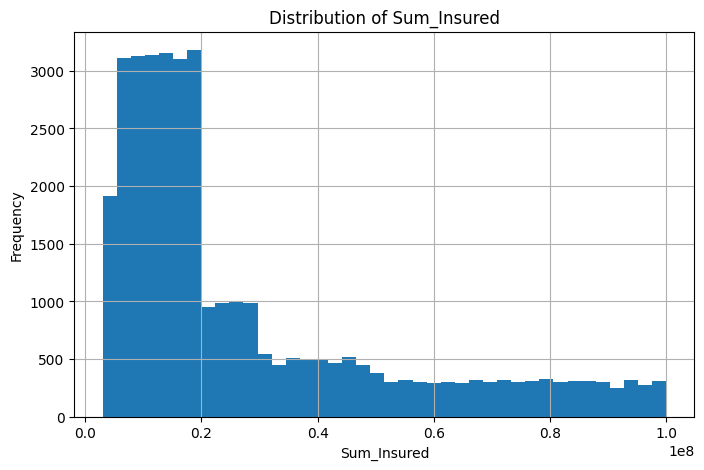

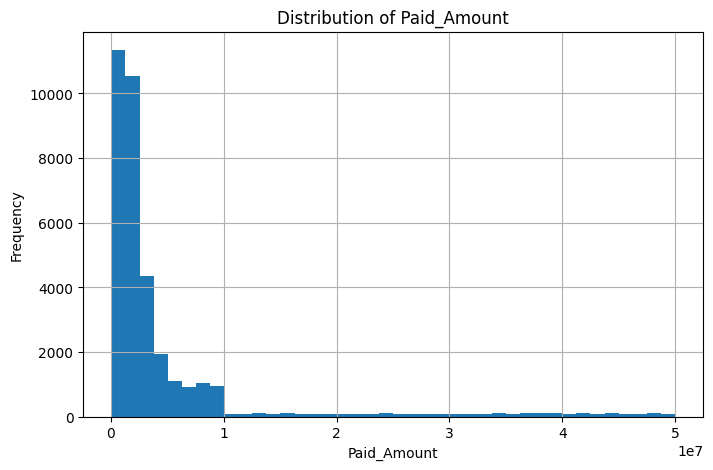

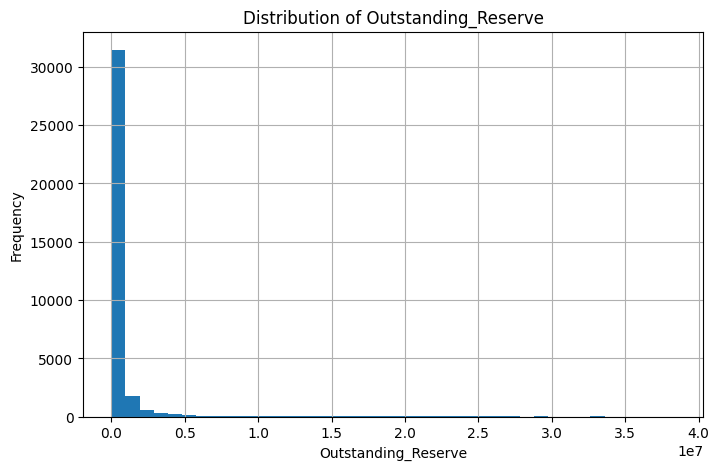

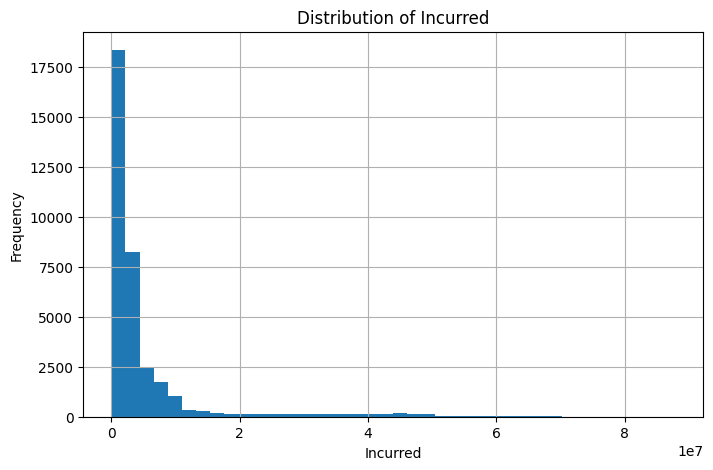

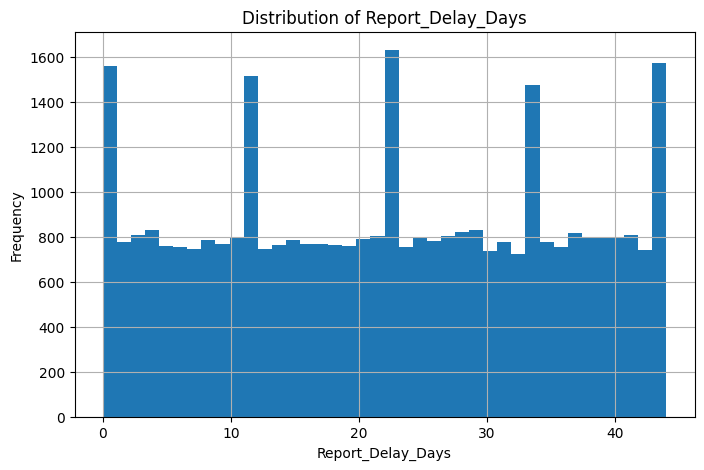

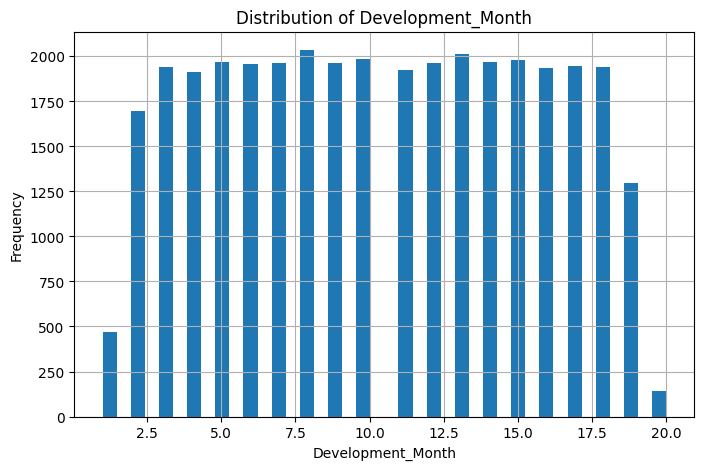

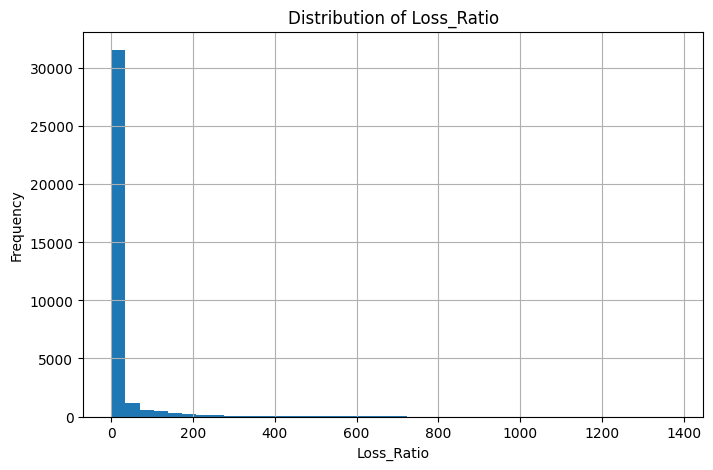

In [14]:
# Histograms for key numerical variables

key_numeric_cols = [
    "Premium",
    "Sum_Insured",
    "Paid_Amount",
    "Outstanding_Reserve",
    "Incurred",
    "Report_Delay_Days",
    "Development_Month",
    "Loss_Ratio"
]

for col in key_numeric_cols:
    plt.figure(figsize=(8,5))
    df[col].dropna().hist(bins=40)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

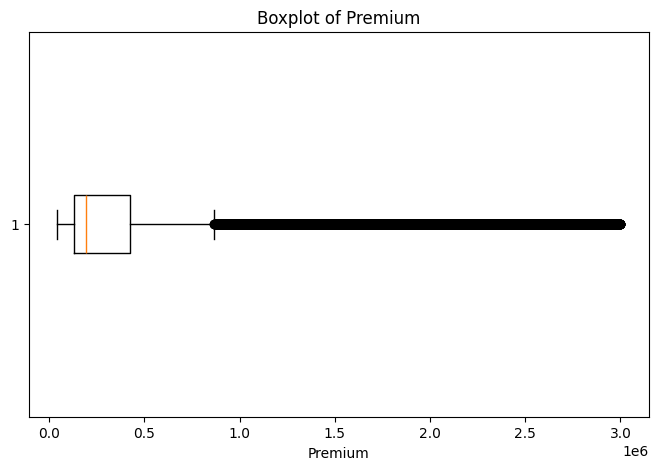

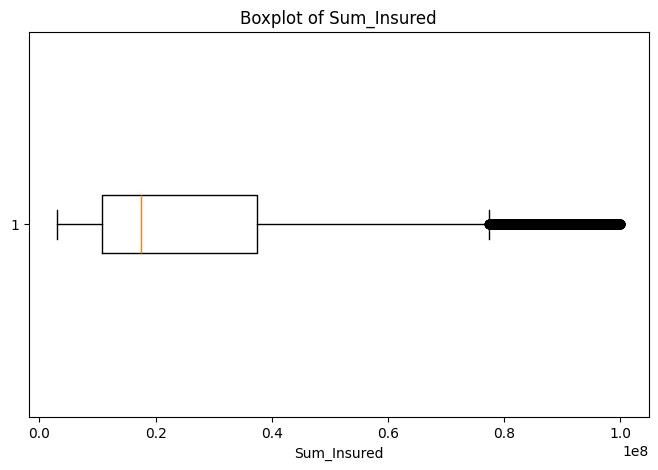

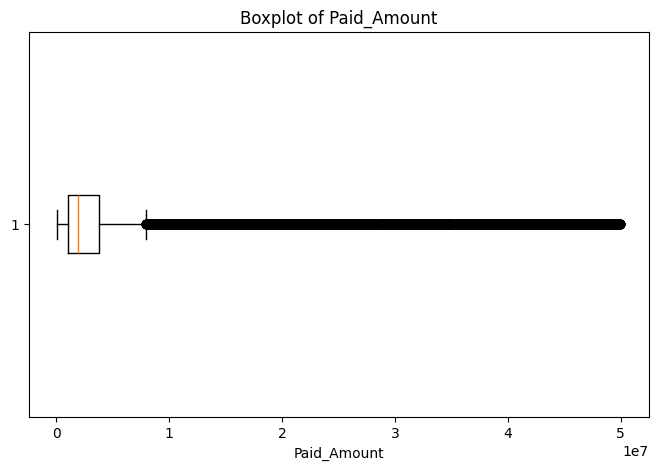

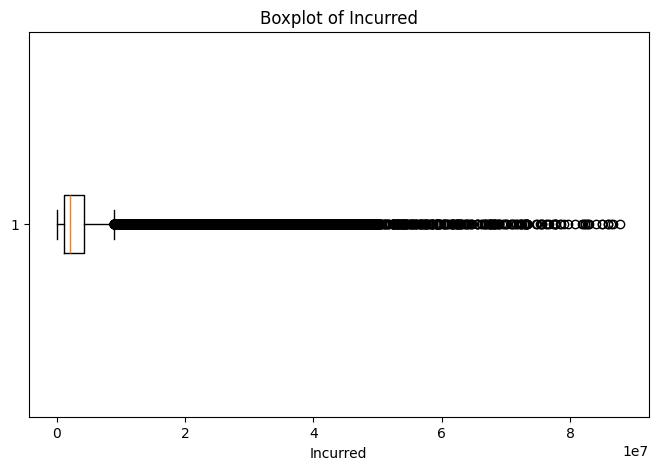

In [15]:
# Boxplots for main monetary variables

monetary_cols = ["Premium", "Sum_Insured", "Paid_Amount", "Incurred"]

for col in monetary_cols:
    plt.figure(figsize=(8,5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

# **EDA BIVARIADO**

In [16]:
# ====================================
# 8. Bivariate Analysis - Branch vs Monetary Variables
# ====================================

branch_summary = df.groupby("Branch").agg(
    Claims=("Claim_ID", "count"),
    Total_Premium=("Premium", "sum"),
    Total_Paid=("Paid_Amount", "sum"),
    Total_Outstanding=("Outstanding_Reserve", "sum"),
    Total_Incurred=("Incurred", "sum"),
    Avg_Paid=("Paid_Amount", "mean"),
    Avg_Incurred=("Incurred", "mean"),
    Avg_Loss_Ratio=("Loss_Ratio", "mean"),
    Avg_Report_Delay=("Report_Delay_Days", "mean"),
    Avg_Development_Month=("Development_Month", "mean")
).sort_values("Total_Incurred", ascending=False)

branch_summary

,Claims,Total_Premium,Total_Paid,Total_Outstanding,Total_Incurred,Avg_Paid,Avg_Incurred,Avg_Loss_Ratio,Avg_Report_Delay,Avg_Development_Month
Branch,,,,,,,,,,
Vida,3479,939836623,89037021644,9367395990,98404417634,"25,592,705.27","28,285,259.45",146.89,22.33,10.34
ART,7083,12401120857,36792844870,3867480166,40660325036,"5,194,528.43","5,740,551.33",4.11,22.06,10.28
Auto,15671,2579215305,23863374611,2516516761,26379891372,"1,522,772.93","1,683,357.24",11.30,21.97,10.32
Comercio,3421,1159675346,8688305109,944778745,9633083854,"2,539,697.49","2,815,867.83",10.86,21.66,10.23
Hogar,5346,587618698,5452174496,607863858,6060038354,"1,019,860.55","1,133,564.97",12.19,22.17,10.39


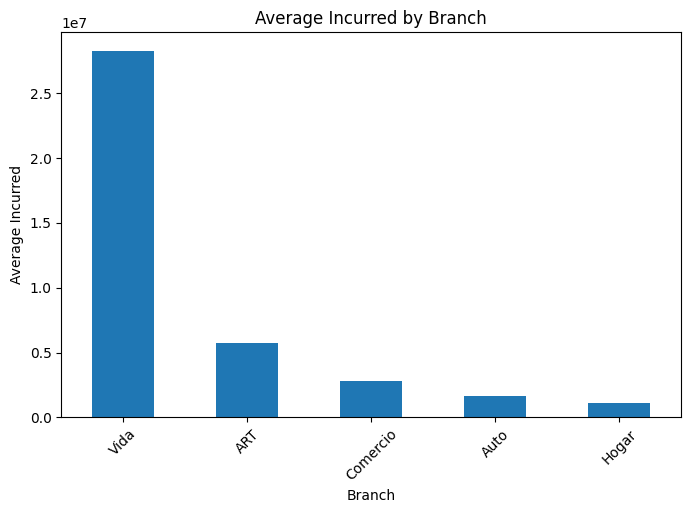

In [17]:
# Average incurred by branch

avg_incurred_by_branch = df.groupby("Branch")["Incurred"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_incurred_by_branch.plot(kind="bar")
plt.title("Average Incurred by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Incurred")
plt.xticks(rotation=45)
plt.show()

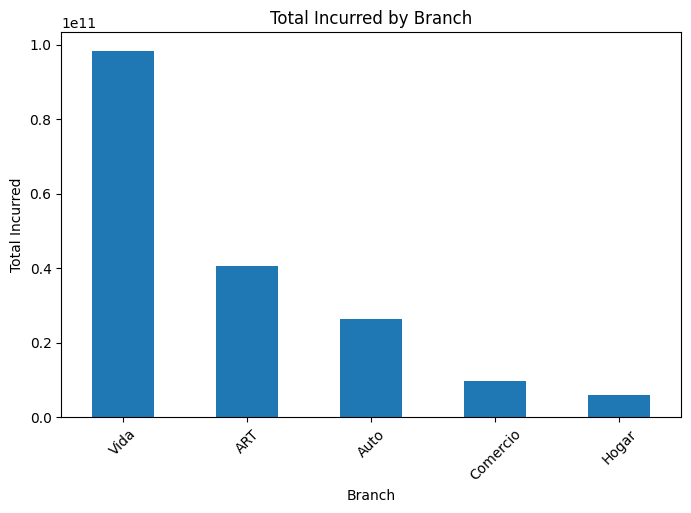

In [18]:
# Total incurred by branch

total_incurred_by_branch = df.groupby("Branch")["Incurred"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
total_incurred_by_branch.plot(kind="bar")
plt.title("Total Incurred by Branch")
plt.xlabel("Branch")
plt.ylabel("Total Incurred")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3556/4072805568.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=branches_order, vert=True)


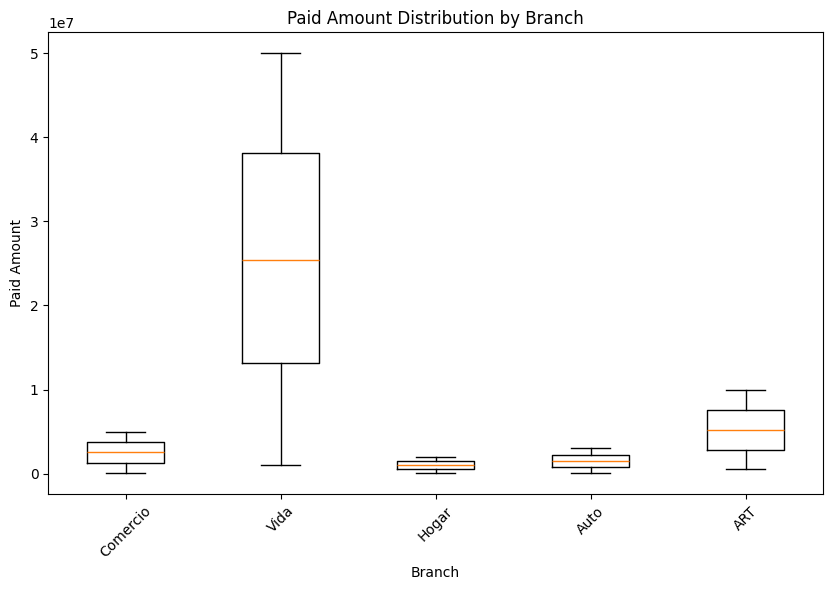

In [19]:
# Paid Amount by Branch - boxplot

branches_order = df["Branch"].dropna().unique()

data_to_plot = [
    df.loc[df["Branch"] == branch, "Paid_Amount"].dropna()
    for branch in branches_order
]

plt.figure(figsize=(10,6))
plt.boxplot(data_to_plot, labels=branches_order, vert=True)
plt.title("Paid Amount Distribution by Branch")
plt.xlabel("Branch")
plt.ylabel("Paid Amount")
plt.xticks(rotation=45)
plt.show()

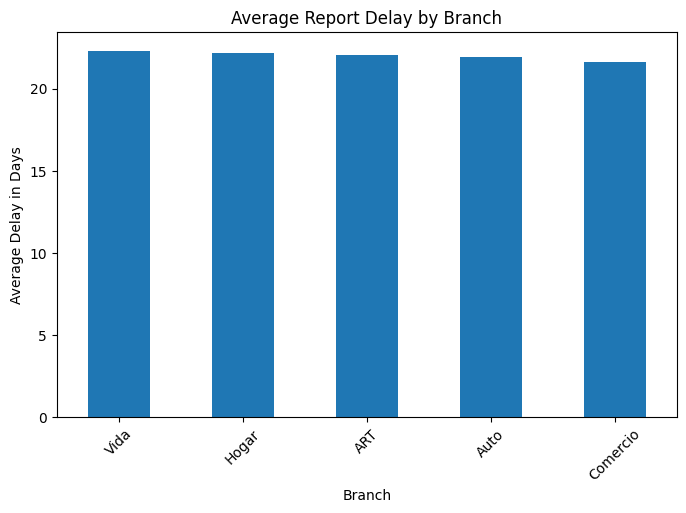

In [20]:
# Report delay by branch

avg_delay_by_branch = df.groupby("Branch")["Report_Delay_Days"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_delay_by_branch.plot(kind="bar")
plt.title("Average Report Delay by Branch")
plt.xlabel("Branch")
plt.ylabel("Average Delay in Days")
plt.xticks(rotation=45)
plt.show()

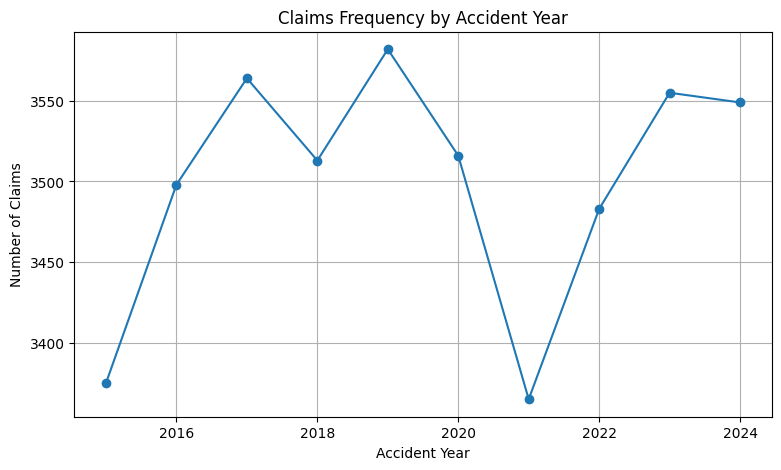

In [21]:
# Claims by accident year

claims_by_year = df.groupby("Accident_Year")["Claim_ID"].count()

plt.figure(figsize=(9,5))
claims_by_year.plot(kind="line", marker="o")
plt.title("Claims Frequency by Accident Year")
plt.xlabel("Accident Year")
plt.ylabel("Number of Claims")
plt.grid(True)
plt.show()

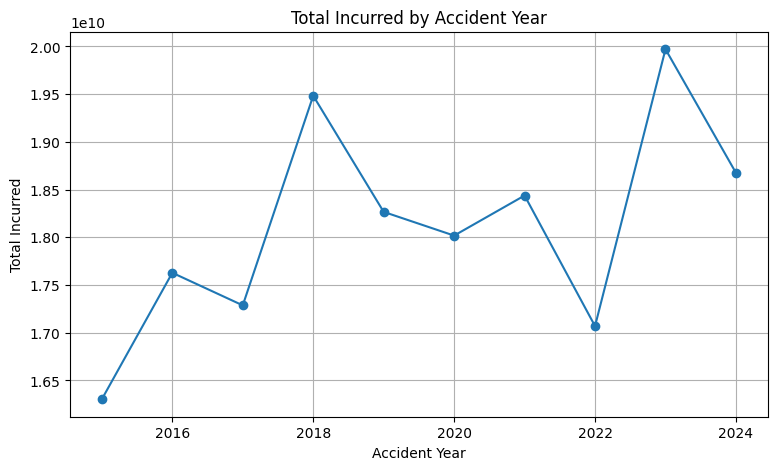

In [22]:
# Incurred by accident year

incurred_by_year = df.groupby("Accident_Year")["Incurred"].sum()

plt.figure(figsize=(9,5))
incurred_by_year.plot(kind="line", marker="o")
plt.title("Total Incurred by Accident Year")
plt.xlabel("Accident Year")
plt.ylabel("Total Incurred")
plt.grid(True)
plt.show()

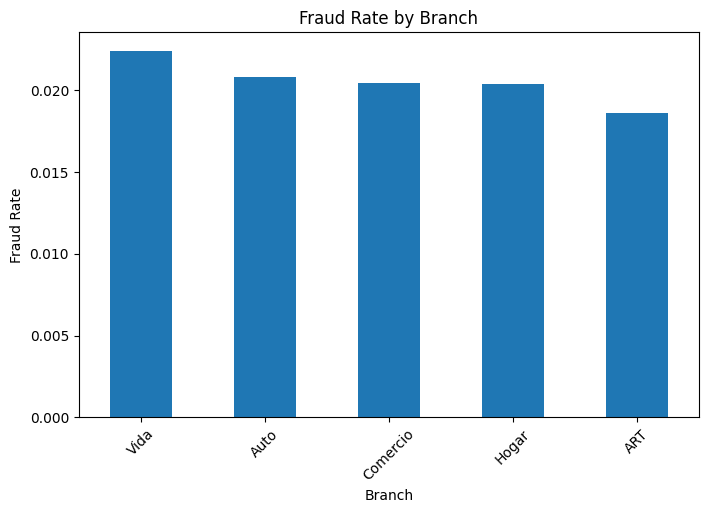

In [23]:
# Fraud by branch

fraud_by_branch = df.groupby("Branch")["Fraud_Flag"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
fraud_by_branch.plot(kind="bar")
plt.title("Fraud Rate by Branch")
plt.xlabel("Branch")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.show()

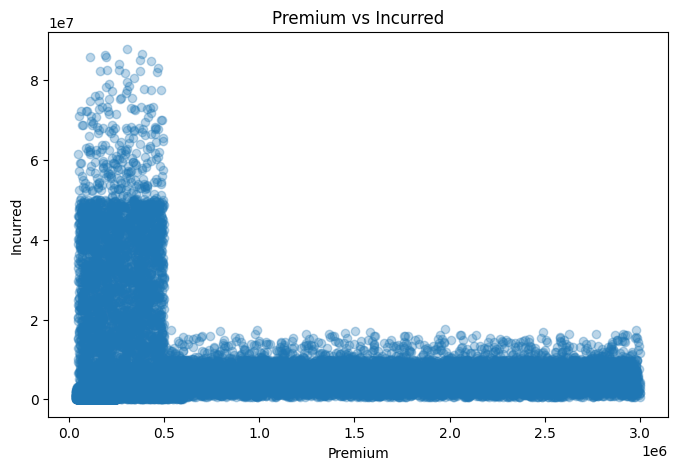

In [24]:
# Relationship between Premium and Incurred

plt.figure(figsize=(8,5))
plt.scatter(df["Premium"], df["Incurred"], alpha=0.3)
plt.title("Premium vs Incurred")
plt.xlabel("Premium")
plt.ylabel("Incurred")
plt.show()

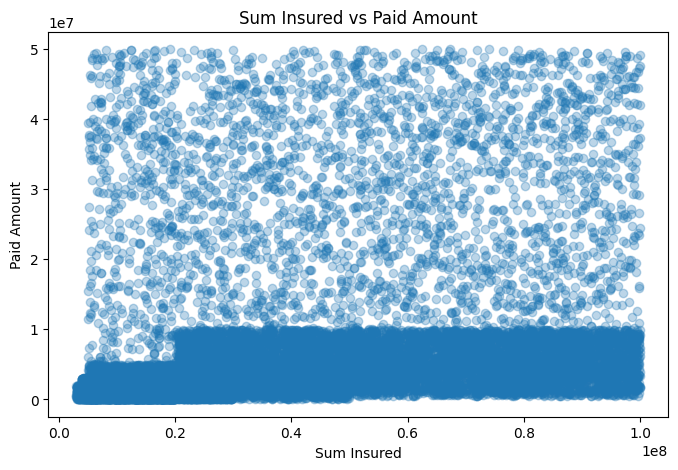

In [25]:
# Relationship between Sum Insured and Paid Amount

plt.figure(figsize=(8,5))
plt.scatter(df["Sum_Insured"], df["Paid_Amount"], alpha=0.3)
plt.title("Sum Insured vs Paid Amount")
plt.xlabel("Sum Insured")
plt.ylabel("Paid Amount")
plt.show()

# **EDA MULTIVARIADO**

In [26]:
# ====================================
# 9. Multivariate Analysis
# ====================================

pivot_branch_year = pd.pivot_table(
    df,
    values="Incurred",
    index="Accident_Year",
    columns="Branch",
    aggfunc="sum"
)

pivot_branch_year

Branch,ART,Auto,Comercio,Hogar,Vida
Accident_Year,,,,,
2015,3842559089,2582743938,960494152,590964296,8326161218
2016,3972128154,2671162092,955196604,605358358,9424116926
2017,3752430722,2793688775,1079252695,620554039,9040583392
2018,4267489592,2489605864,971887609,598063835,11156166832
2019,4233758513,2731158519,921131027,633708639,9746463117
2020,4069064491,2684416414,937111170,609693379,9717316761
2021,3908917499,2498532046,939590711,593046163,10497557623
2022,4195371911,2623684532,934973283,578365552,8736918081
2023,4095518316,2710817732,1053784631,592293470,11518441112


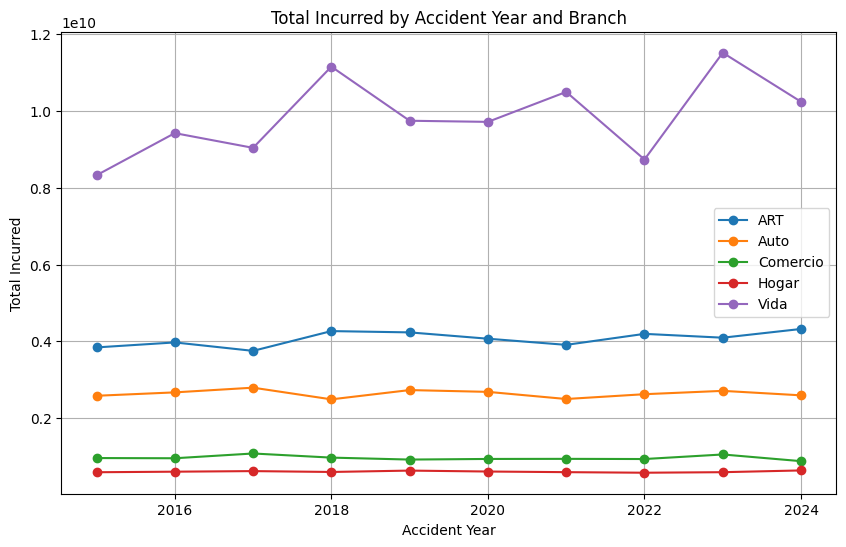

In [27]:
# Incurred by Accident Year and Branch

plt.figure(figsize=(10,6))

for branch in pivot_branch_year.columns:
    plt.plot(
        pivot_branch_year.index,
        pivot_branch_year[branch],
        marker="o",
        label=branch
    )

plt.title("Total Incurred by Accident Year and Branch")
plt.xlabel("Accident Year")
plt.ylabel("Total Incurred")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
# Claims frequency by Accident Year and Branch

pivot_claims_year_branch = pd.pivot_table(
    df,
    values="Claim_ID",
    index="Accident_Year",
    columns="Branch",
    aggfunc="count"
)

pivot_claims_year_branch

Branch,ART,Auto,Comercio,Hogar,Vida
Accident_Year,,,,,
2015,678,1521,338,525,313
2016,701,1582,340,531,344
2017,669,1638,385,551,321
2018,731,1523,338,525,396
2019,740,1611,342,561,328
2020,720,1574,335,532,355
2021,685,1469,327,517,367
2022,735,1582,329,521,316
2023,684,1594,366,529,382


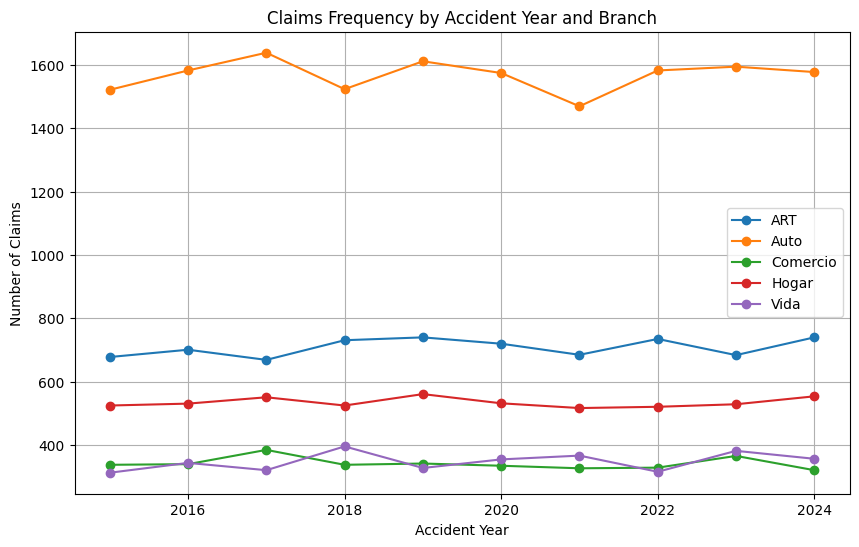

In [29]:
plt.figure(figsize=(10,6))

for branch in pivot_claims_year_branch.columns:
    plt.plot(
        pivot_claims_year_branch.index,
        pivot_claims_year_branch[branch],
        marker="o",
        label=branch
    )

plt.title("Claims Frequency by Accident Year and Branch")
plt.xlabel("Accident Year")
plt.ylabel("Number of Claims")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
# Loss Ratio by Branch and Accident Year

pivot_loss_ratio = pd.pivot_table(
    df,
    values="Loss_Ratio",
    index="Accident_Year",
    columns="Branch",
    aggfunc="mean"
)

pivot_loss_ratio

Branch,ART,Auto,Comercio,Hogar,Vida
Accident_Year,,,,,
2015,4.22,11.49,11.49,12.65,138.90
2016,3.96,11.40,11.19,12.28,137.46
2017,3.94,11.36,10.65,12.33,140.52
2018,4.18,10.95,11.32,12.51,146.16
2019,4.11,11.35,10.57,11.76,149.73
2020,4.07,11.38,10.38,12.22,146.21
2021,4.05,11.34,10.08,12.37,136.86
2022,4.22,11.10,11.19,11.59,144.94
2023,4.24,11.52,11.27,11.57,171.96


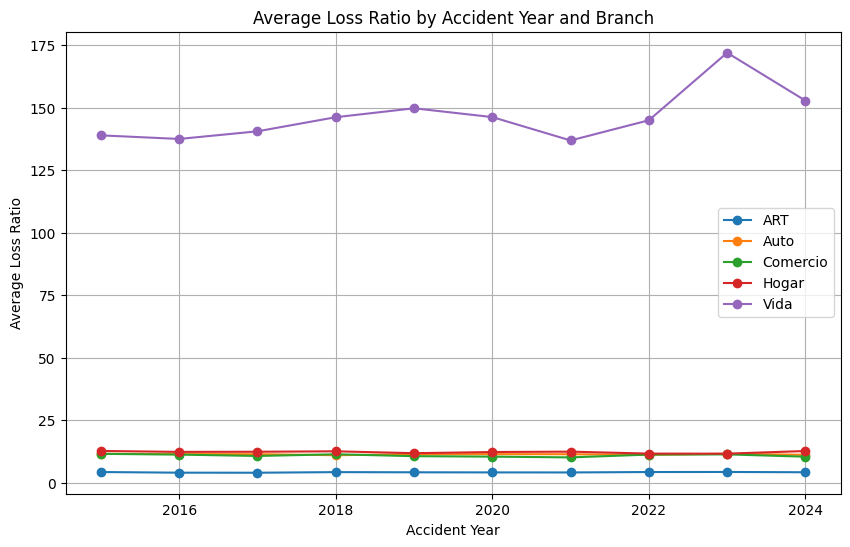

In [31]:
plt.figure(figsize=(10,6))

for branch in pivot_loss_ratio.columns:
    plt.plot(
        pivot_loss_ratio.index,
        pivot_loss_ratio[branch],
        marker="o",
        label=branch
    )

plt.title("Average Loss Ratio by Accident Year and Branch")
plt.xlabel("Accident Year")
plt.ylabel("Average Loss Ratio")
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# Correlation matrix

corr_cols = [
    "Premium",
    "Sum_Insured",
    "Paid_Amount",
    "Outstanding_Reserve",
    "Incurred",
    "Report_Delay_Days",
    "Development_Month",
    "Customer_Age",
    "Loss_Ratio",
    "Reserve_Ratio",
    "Paid_to_Sum_Insured",
    "Fraud_Flag"
]

corr_matrix = df[corr_cols].corr()

corr_matrix

,Premium,Sum_Insured,Paid_Amount,Outstanding_Reserve,Incurred,Report_Delay_Days,Development_Month,Customer_Age,Loss_Ratio,Reserve_Ratio,Paid_to_Sum_Insured,Fraud_Flag
Premium,1.00,0.59,0.06,0.03,0.06,0.01,-0.00,0.00,-0.15,-0.00,-0.08,-0.00
Sum_Insured,0.59,1.00,0.40,0.15,0.39,0.00,-0.00,0.00,0.18,-0.00,-0.08,-0.00
Paid_Amount,0.06,0.40,1.00,0.40,0.98,0.00,-0.00,-0.01,0.75,-0.00,0.62,0.01
Outstanding_Reserve,0.03,0.15,0.40,1.00,0.58,0.01,0.01,0.01,0.42,0.43,0.25,0.01
Incurred,0.06,0.39,0.98,0.58,1.00,0.00,0.00,-0.01,0.76,0.10,0.60,0.01
Report_Delay_Days,0.01,0.00,0.00,0.01,0.00,1.00,0.08,0.00,0.00,0.00,0.01,-0.00
Development_Month,-0.00,-0.00,-0.00,0.01,0.00,0.08,1.00,-0.00,0.00,-0.01,0.00,0.01
Customer_Age,0.00,0.00,-0.01,0.01,-0.01,0.00,-0.00,1.00,-0.01,0.01,-0.01,-0.01
Loss_Ratio,-0.15,0.18,0.75,0.42,0.76,0.00,0.00,-0.01,1.00,0.06,0.49,-0.00
Reserve_Ratio,-0.00,-0.00,-0.00,0.43,0.10,0.00,-0.01,0.01,0.06,1.00,-0.00,0.00


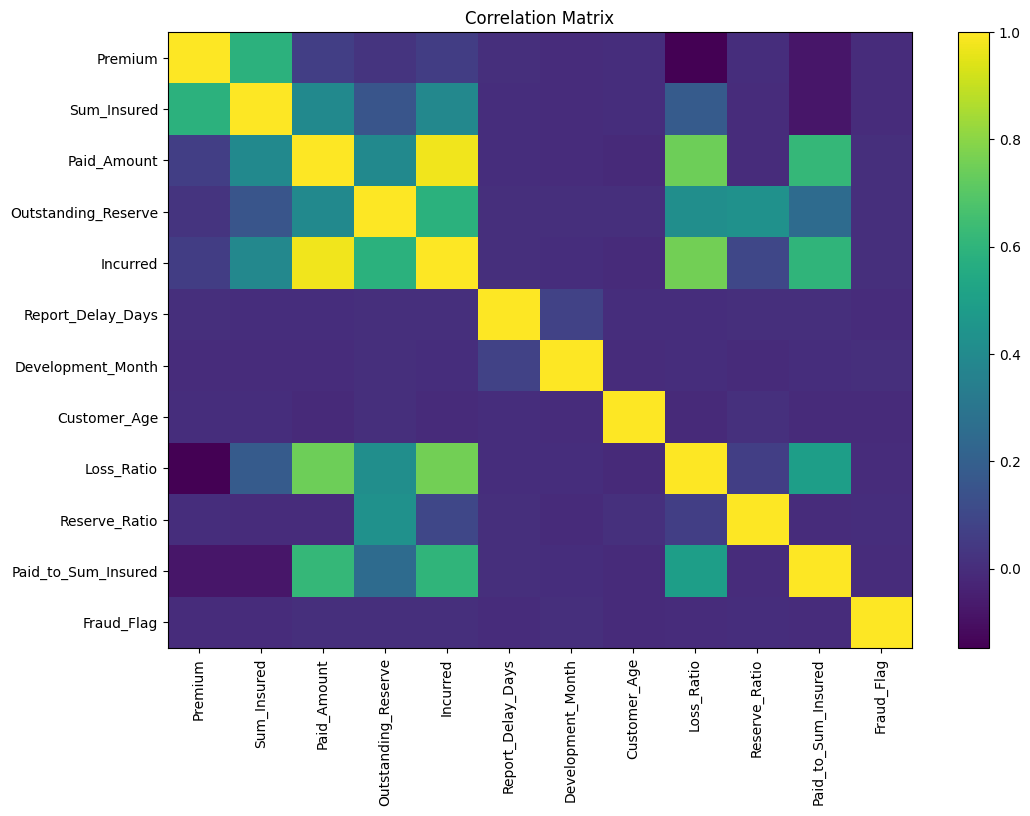

In [33]:
# Correlation heatmap using matplotlib

plt.figure(figsize=(12,8))
plt.imshow(corr_matrix, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.index)), corr_matrix.index)
plt.title("Correlation Matrix")
plt.show()

In [34]:
# Multivariate segmentation:
# Branch + Status + Fraud Flag

multi_summary = df.groupby(["Branch", "Status", "Fraud_Flag"]).agg(
    Claims=("Claim_ID", "count"),
    Avg_Paid=("Paid_Amount", "mean"),
    Avg_Incurred=("Incurred", "mean"),
    Avg_Loss_Ratio=("Loss_Ratio", "mean")
).reset_index()

multi_summary

,Branch,Status,Fraud_Flag,Claims,Avg_Paid,Avg_Incurred,Avg_Loss_Ratio
0,ART,Closed,0,5216,"5,213,192.35","5,213,192.35",3.76
1,ART,Closed,1,90,"5,327,700.92","5,327,700.92",3.59
2,ART,Open,0,1735,"5,114,496.30","7,279,150.95",5.14
3,ART,Open,1,42,"5,897,367.29","8,559,375.36",6.16
4,Auto,Closed,0,11496,"1,528,091.17","1,528,091.17",10.25
5,Auto,Closed,1,254,"1,522,958.89","1,522,958.89",10.12
6,Auto,Open,0,3849,"1,509,996.30","2,152,719.31",14.49
7,Auto,Open,1,72,"1,355,989.67","1,948,710.39",13.33
8,Comercio,Closed,0,2508,"2,521,016.53","2,521,016.53",9.90
9,Comercio,Closed,1,49,"2,827,944.55","2,827,944.55",9.20


In [35]:
# Development month by Branch

development_summary = df.groupby("Branch").agg(
    Avg_Development_Month=("Development_Month", "mean"),
    Median_Development_Month=("Development_Month", "median"),
    Max_Development_Month=("Development_Month", "max")
).sort_values("Avg_Development_Month", ascending=False)

development_summary

,Avg_Development_Month,Median_Development_Month,Max_Development_Month
Branch,,,
Hogar,10.39,10.00,20
Vida,10.34,10.00,20
Auto,10.32,10.00,20
ART,10.28,10.00,20
Comercio,10.23,10.00,20


In [36]:
# Reserve analysis by branch

reserve_summary = df.groupby("Branch").agg(
    Total_Outstanding=("Outstanding_Reserve", "sum"),
    Total_Incurred=("Incurred", "sum"),
    Avg_Reserve_Ratio=("Reserve_Ratio", "mean")
)

reserve_summary["Outstanding_as_%_of_Incurred"] = (
    reserve_summary["Total_Outstanding"] / reserve_summary["Total_Incurred"]
)

reserve_summary.sort_values("Outstanding_as_%_of_Incurred", ascending=False)

,Total_Outstanding,Total_Incurred,Avg_Reserve_Ratio,Outstanding_as_%_of_Incurred
Branch,,,,
Hogar,607863858,6060038354,0.07,0.10
Comercio,944778745,9633083854,0.07,0.10
Auto,2516516761,26379891372,0.07,0.10
Vida,9367395990,98404417634,0.07,0.10
ART,3867480166,40660325036,0.07,0.10


# **EXECUTIVE SUMMARY AUTOMÁTICO**

In [37]:
# ====================================
# 10. Executive Summary
# ====================================

total_claims = len(df)
total_premium = df["Premium"].sum()
total_paid = df["Paid_Amount"].sum()
total_outstanding = df["Outstanding_Reserve"].sum()
total_incurred = df["Incurred"].sum()

top_branch_by_claims = df["Branch"].value_counts().idxmax()
top_branch_by_incurred = df.groupby("Branch")["Incurred"].sum().idxmax()
highest_avg_severity_branch = df.groupby("Branch")["Incurred"].mean().idxmax()
highest_loss_ratio_branch = df.groupby("Branch")["Loss_Ratio"].mean().idxmax()
avg_report_delay = df["Report_Delay_Days"].mean()
avg_development_month = df["Development_Month"].mean()
open_claim_rate = (df["Status"] == "Open").mean()
fraud_rate = df["Fraud_Flag"].mean()

summary = f"""
EXECUTIVE SUMMARY

Portfolio Overview
------------------
Total claims analyzed: {total_claims:,.0f}
Total premium: {total_premium:,.0f}
Total paid amount: {total_paid:,.0f}
Total outstanding reserve: {total_outstanding:,.0f}
Total incurred: {total_incurred:,.0f}

Key Findings
------------
1. The branch with the highest number of claims is {top_branch_by_claims}.
2. The branch with the highest total incurred amount is {top_branch_by_incurred}.
3. The branch with the highest average severity is {highest_avg_severity_branch}.
4. The branch with the highest average loss ratio is {highest_loss_ratio_branch}.
5. Average report delay is {avg_report_delay:.1f} days.
6. Average development month is {avg_development_month:.1f} months.
7. Open claim rate is {open_claim_rate:.2%}.
8. Fraud flag rate is {fraud_rate:.2%}.

Actuarial Interpretation
------------------------
The portfolio shows differences in frequency and severity across branches.
Branches with high incurred amounts and high loss ratios should be prioritized
for further reserving, pricing and risk analysis.

Next Steps
----------
1. Build development triangles by accident year and development month.
2. Estimate IBNR reserves using the Chain Ladder method.
3. Compare paid and incurred development patterns.
4. Develop a Power BI dashboard for portfolio monitoring.
"""

print(summary)


EXECUTIVE SUMMARY

Portfolio Overview
------------------
Total claims analyzed: 35,000
Total premium: 17,667,466,829
Total paid amount: 163,833,720,730
Total outstanding reserve: 17,304,035,520
Total incurred: 181,137,756,250

Key Findings
------------
1. The branch with the highest number of claims is Auto.
2. The branch with the highest total incurred amount is Vida.
3. The branch with the highest average severity is Vida.
4. The branch with the highest average loss ratio is Vida.
5. Average report delay is 22.0 days.
6. Average development month is 10.3 months.
7. Open claim rate is 25.09%.
8. Fraud flag rate is 2.04%.

Actuarial Interpretation
------------------------
The portfolio shows differences in frequency and severity across branches.
Branches with high incurred amounts and high loss ratios should be prioritized
for further reserving, pricing and risk analysis.

Next Steps
----------
1. Build development triangles by accident year and development month.
2. Estimate IBNR res

#**EXPORTAR RESULTADOS**

In [40]:
# ====================================
# 11. Export EDA Tables
# ====================================

with pd.ExcelWriter("eda_summary_tables.xlsx") as writer:
    branch_summary.to_excel(writer, sheet_name="Branch Summary")
    pivot_branch_year.to_excel(writer, sheet_name="Incurred by Year Branch")
    pivot_claims_year_branch.to_excel(writer, sheet_name="Claims by Year Branch")
    pivot_loss_ratio.to_excel(writer, sheet_name="Loss Ratio")
    corr_matrix.to_excel(writer, sheet_name="Correlation Matrix")
    multi_summary.to_excel(writer, sheet_name="Multivariate Summary", index=False)
    development_summary.to_excel(writer, sheet_name="Development Summary")
    reserve_summary.to_excel(writer, sheet_name="Reserve Summary")

print("EDA summary tables exported successfully.")

EDA summary tables exported successfully.


In [41]:
from google.colab import files

files.download("eda_summary_tables.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>